In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

print("All libraries loaded!")

All libraries loaded!


In [2]:
from google.colab import files
uploaded = files.upload()

Saving 7120ced0-18a0-4b0c-9dac-5f3bc9b396fc.csv to 7120ced0-18a0-4b0c-9dac-5f3bc9b396fc.csv


In [3]:
import os
print(os.listdir('/content'))

['.config', '7120ced0-18a0-4b0c-9dac-5f3bc9b396fc.csv', 'sample_data']


In [4]:
df = pd.read_csv('/content/7120ced0-18a0-4b0c-9dac-5f3bc9b396fc.csv')
print(df.shape)
print(df.head())
print(df.describe())
print(df['target_5yrs'].value_counts())

(1340, 11)
     fg    3p    ft  reb  ast  stl  blk  tov  target_5yrs  total_points  \
0  34.7  25.0  69.9  4.1  1.9  0.4  0.4  1.3            0         266.4   
1  29.6  23.5  76.5  2.4  3.7  1.1  0.5  1.6            0         252.0   
2  42.2  24.4  67.0  2.2  1.0  0.5  0.3  1.0            0         384.8   
3  42.6  22.6  68.9  1.9  0.8  0.6  0.1  1.0            1         330.6   
4  52.4   0.0  67.4  2.5  0.3  0.3  0.4  0.8            1         216.0   

   efficiency  
0    0.270073  
1    0.267658  
2    0.339869  
3    0.491379  
4    0.391304  
                fg           3p           ft          reb          ast  \
count  1340.000000  1340.000000  1340.000000  1340.000000  1340.000000   
mean     44.169403    19.149627    70.300299     3.034478     1.550522   
std       6.137679    16.051861    10.578479     2.057774     1.471169   
min      23.800000     0.000000     0.000000     0.300000     0.000000   
25%      40.200000     0.000000    64.700000     1.500000     0.600000  

In [5]:
# Separate features and target
X = df.drop('target_5yrs', axis=1)
y = df['target_5yrs']

# Split data 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (1072, 10)
Testing set size: (268, 10)


In [6]:
# Build Gaussian Naive Bayes model
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

# Make predictions
y_pred = gnb.predict(X_test_scaled)

print("Model trained successfully!")
print()
print("Sample predictions:", y_pred[:10])
print("Actual values:     ", list(y_test[:10]))

Model trained successfully!

Sample predictions: [0 0 1 0 0 0 0 0 0 0]
Actual values:      [0, 1, 1, 1, 0, 1, 1, 0, 0, 1]


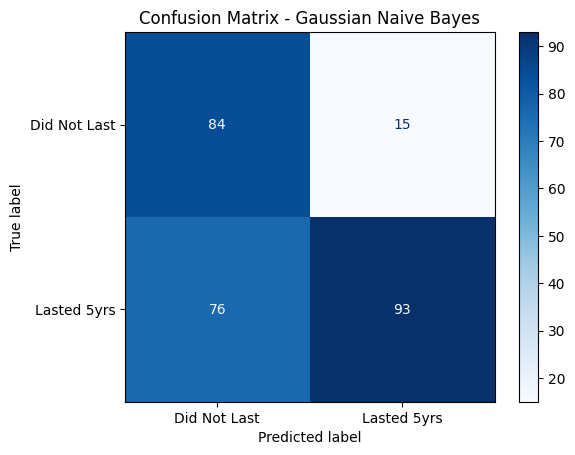

Confusion Matrix:
[[84 15]
 [76 93]]


In [7]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Did Not Last', 'Lasted 5yrs'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Gaussian Naive Bayes')
plt.show()

print("Confusion Matrix:")
print(cm)

In [8]:
# Evaluation metrics
print("=" * 50)
print("MODEL PERFORMANCE METRICS")
print("=" * 50)
print()
print("Accuracy: ", round((84+93)/268, 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:   ", round(recall_score(y_test, y_pred), 3))
print("F1-Score: ", round(f1_score(y_test, y_pred), 3))
print()
print(classification_report(y_test, y_pred,
      target_names=['Did Not Last', 'Lasted 5yrs']))

MODEL PERFORMANCE METRICS

Accuracy:  0.66
Precision: 0.861
Recall:    0.55
F1-Score:  0.671

              precision    recall  f1-score   support

Did Not Last       0.53      0.85      0.65        99
 Lasted 5yrs       0.86      0.55      0.67       169

    accuracy                           0.66       268
   macro avg       0.69      0.70      0.66       268
weighted avg       0.74      0.66      0.66       268



In [9]:
print("=" * 60)
print("NAIVE BAYES NBA LONGEVITY - KEY FINDINGS")
print("=" * 60)
print()
print("MODEL PERFORMANCE:")
print("Accuracy:  66%")
print("Precision: 86.1% — when model predicts longevity it is")
print("           right 86% of the time (low bust rate)")
print("Recall:    55.0% — model catches 55% of long-term players")
print("           meaning 45% of talent is missed")
print("F1-Score:  67.1%")
print()
print("CONFUSION MATRIX RESULTS:")
print("True Positives:  93  correctly predicted lasted 5yrs")
print("True Negatives:  84  correctly predicted did not last")
print("False Positives: 15  predicted lasted but did not (busts)")
print("False Negatives: 76  predicted did not last but did (missed)")
print()
print("INDEPENDENCE ASSUMPTION ANALYSIS:")
print("Naive Bayes assumes all features are independent")
print("However basketball stats ARE correlated:")
print("- More minutes played = more points scored")
print("- More shots taken = more points scored")
print("This violates the independence assumption")
print("which explains the model's moderate accuracy")
print()
print("SCOUTING RECOMMENDATIONS:")
print("1. Use model to SHORTLIST players not make final decisions")
print("2. High precision means recommended players are reliable")
print("3. Low recall means scouts must still watch film")
print("4. Combine model with qualitative scouting insights")
print("5. Consider Random Forest for better accuracy")
print("=" * 60)

NAIVE BAYES NBA LONGEVITY - KEY FINDINGS

MODEL PERFORMANCE:
Accuracy:  66%
Precision: 86.1% — when model predicts longevity it is
           right 86% of the time (low bust rate)
Recall:    55.0% — model catches 55% of long-term players
           meaning 45% of talent is missed
F1-Score:  67.1%

CONFUSION MATRIX RESULTS:
True Positives:  93  correctly predicted lasted 5yrs
True Negatives:  84  correctly predicted did not last
False Positives: 15  predicted lasted but did not (busts)
False Negatives: 76  predicted did not last but did (missed)

INDEPENDENCE ASSUMPTION ANALYSIS:
Naive Bayes assumes all features are independent
However basketball stats ARE correlated:
- More minutes played = more points scored
- More shots taken = more points scored
This violates the independence assumption
which explains the model's moderate accuracy

SCOUTING RECOMMENDATIONS:
1. Use model to SHORTLIST players not make final decisions
2. High precision means recommended players are reliable
3. Low reca

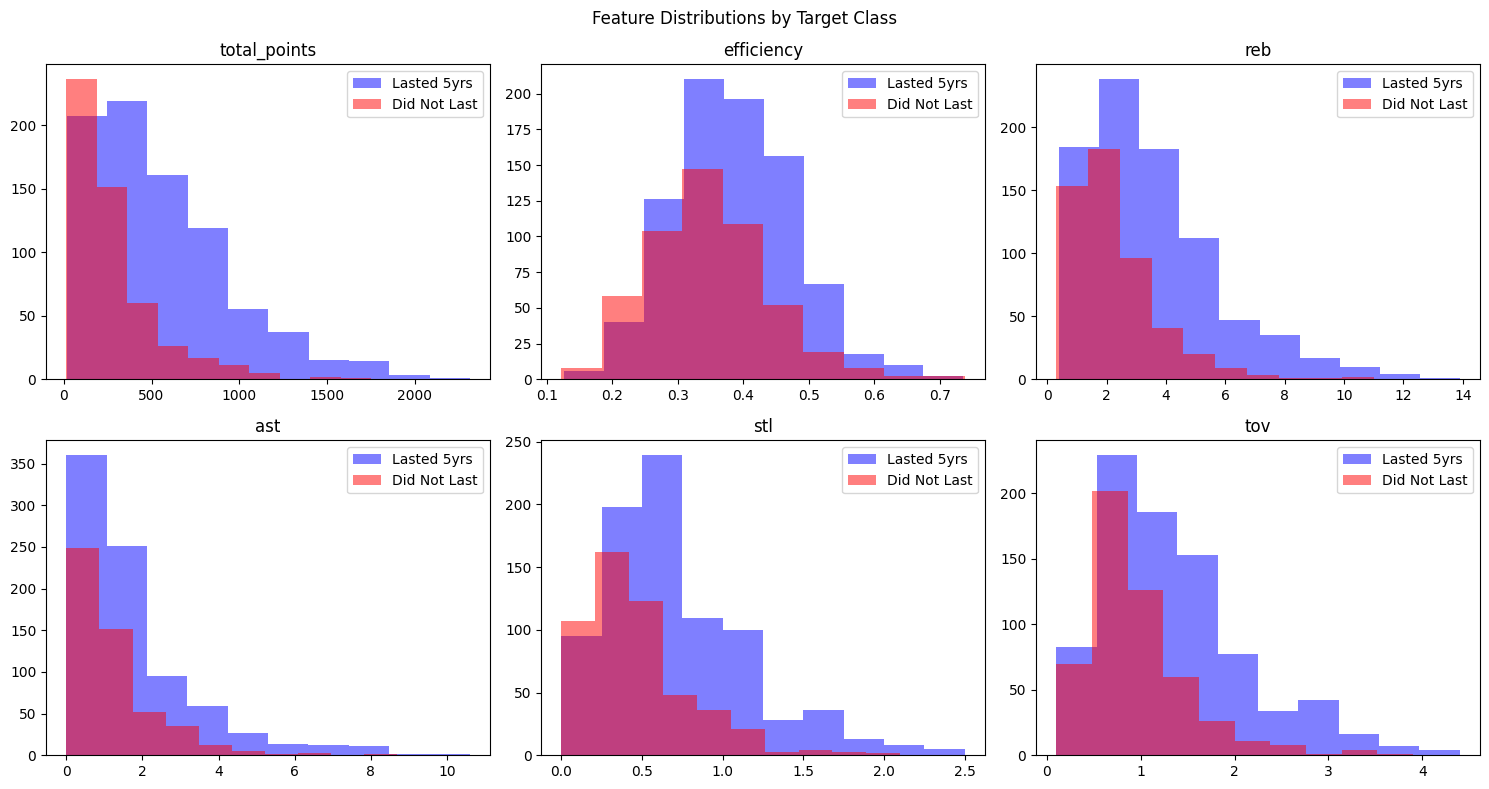

In [10]:
# Plot feature distributions by target
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features = ['total_points', 'efficiency', 'reb', 'ast', 'stl', 'tov']

for i, feature in enumerate(features):
    row = i // 3
    col = i % 3
    axes[row][col].hist(df[df['target_5yrs']==1][feature],
                        alpha=0.5, label='Lasted 5yrs', color='blue')
    axes[row][col].hist(df[df['target_5yrs']==0][feature],
                        alpha=0.5, label='Did Not Last', color='red')
    axes[row][col].set_title(feature)
    axes[row][col].legend()

plt.suptitle('Feature Distributions by Target Class')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2083/2973843044.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target_5yrs', data=df,


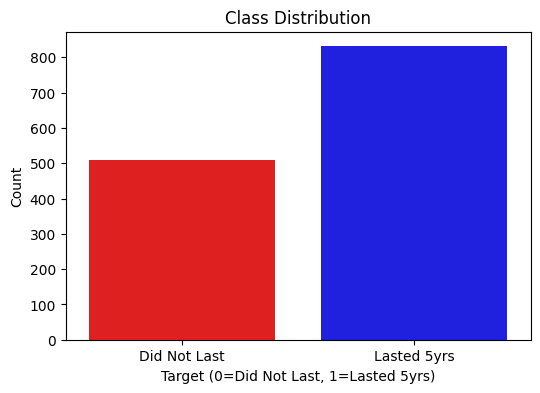

Class distribution:
target_5yrs
1    831
0    509
Name: count, dtype: int64


In [11]:
# Class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='target_5yrs', data=df,
              palette=['red', 'blue'])
plt.title('Class Distribution')
plt.xlabel('Target (0=Did Not Last, 1=Lasted 5yrs)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Did Not Last', 'Lasted 5yrs'])
plt.show()

print("Class distribution:")
print(df['target_5yrs'].value_counts())